In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [8]:
df = pd.read_csv(r'C:\Users\Muhammad Saad\OneDrive\Desktop\Sms spam classifier\spam.csv',encoding='latin-1')

In [9]:
df.head(2)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN


In [10]:
df.head(2)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN


In [11]:
df = df[['v2','v1']]

In [12]:
df.head(2)

,v2,v1
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham


DATA CLEANING

In [13]:
df.rename(columns={'v2':'text','v1':'label'},inplace=True)

In [14]:
df

,text,label
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham
...,...,...
5567,This is the 2nd time we have tried 2 contact u...,spam
5568,Will Ì_ b going to esplanade fr home?,ham
5569,"Pity, * was in mood for that. So...any other s...",ham
5570,The guy did some bitching but I acted like i'd...,ham


In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

In [16]:
df.duplicated().sum()

np.int64(403)

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df.duplicated().sum()

np.int64(0)

<Axes: >

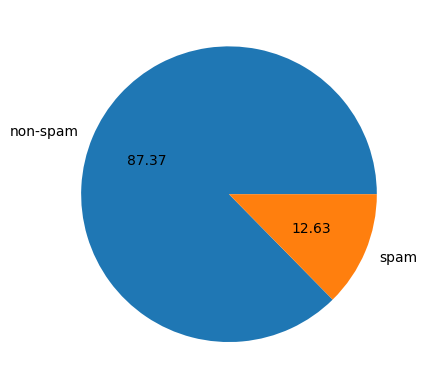

In [19]:
df['label'].value_counts().plot(kind='pie',autopct='%0.2f',labels=['non-spam','spam'])

In [20]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Muhammad
[nltk_data]     Saad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
df['no of characters'] = df['text'].apply(len)

In [22]:
df

,text,label,no of characters
0,"Go until jurong point, crazy.. Available only ...",0,111
1,Ok lar... Joking wif u oni...,0,29
2,Free entry in 2 a wkly comp to win FA Cup fina...,1,155
3,U dun say so early hor... U c already then say...,0,49
4,"Nah I don't think he goes to usf, he lives aro...",0,61
...,...,...,...
5567,This is the 2nd time we have tried 2 contact u...,1,161
5568,Will Ì_ b going to esplanade fr home?,0,37
5569,"Pity, * was in mood for that. So...any other s...",0,57
5570,The guy did some bitching but I acted like i'd...,0,125


In [23]:
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt_tab to C:\Users\Muhammad
[nltk_data]     Saad\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [24]:
df['number of words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [25]:
df['num of sent'] = df['text'].apply(lambda x : len(nltk.sent_tokenize(x)))

In [32]:
df[['no of characters','number of words','num of sent']].describe()

,no of characters,number of words,num of sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [47]:
ham = df[df['label'] == 0][['no of characters','number of words','num of sent']]

In [48]:
spam = df[df['label'] == 1][['no of characters','number of words','num of sent']]

<Axes: xlabel='no of characters', ylabel='Count'>

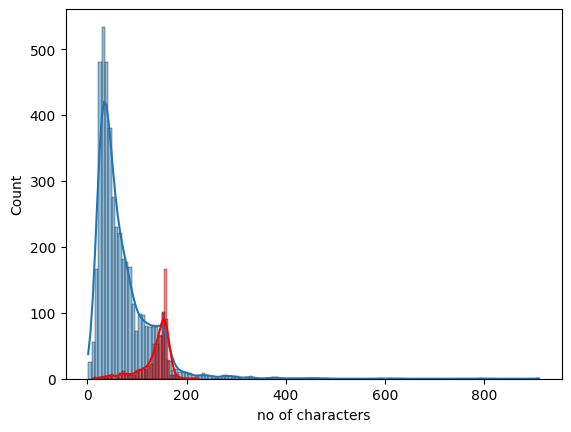

In [52]:
sns.histplot(df[df['label']==0],x='no of characters',kde=True)
sns.histplot(df[df['label']==1],x='no of characters',kde=True,color='red')
